# **Taller 1: Promedios.**
El presente taller tiene como finalidad aplicar **herramientas estadísticas fundamentales** para el análisis cuantitativo de un conjunto de datos. A través del desarrollo de una función en Python y su posterior implementación en datos reales, se busca fortalecer la comprensión y el manejo de conceptos esenciales como la media aritmética, la desviación estándar, la varianza y el coeficiente de variación.

En esta ocasión, el estudio se centrará en el coeficiente de expansión térmica del acero, un parámetro relevante en la ingeniería y la ciencia de los materiales, ya que describe la variación dimensional de un sólido en respuesta a cambios de temperatura. Para ello, se empleará un conjunto de datos experimentales contenidos en el archivo `Datos Taller 1.txt`, los cuales serán procesados utilizando la función previamente desarrollada. Además del análisis numérico, se incluirá una representación gráfica mediante un histograma, lo que permitirá visualizar la distribución de los valores obtenidos.

## **Introducción.**
[**Ejercicio 1:**](#ejercicio-1) Cree una función en Python que, a partir de un conjunto de datos $x_i$, determine el valor promedio de los datos, la desviación estándar, la varianza y el coeficiente de variación.

[**Ejercicio 2:**](#ejercicio-2) A partir de los datos aportados en el archivo `Datos Taller 1.txt`, determine el valor promedio del coeficiente de expansión térmica del acero medido en $[x10^{-6} in/(in \cdot °F)]$, su desviación estándar, varianza y coeficiente de variación utilizando la función realizada en el apartado anterior. Además, cree un histograma de los datos obtenidos.

## **Importaciones de librerias.**
En este apartado se procederá a la importación de las librerías necesarias para la ejecución del taller, las cuales han sido previamente definidas en el archivo **`requirements.txt`**. Esto garantiza la compatibilidad del entorno de trabajo y permite realizar de manera eficiente el procesamiento de datos, el cálculo de métricas estadísticas y la visualización de resultados, asegurando así una correcta ejecución de los ejercicios posteriores.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Ejercicio 1: Desarrollo de una Función para el Cálculo de Parámetros Estadísticos.** <a id="ejercicio-1"></a>
En este ejercicio, se desarrollará una función en Python que, dada una serie de valores numéricos, determine cuatro parámetros estadísticos esenciales:
- **Media aritmética:** Representa el valor promedio del conjunto de datos y es un indicador fundamental de tendencia central.
- **Desviación estándar:** Mide el grado de dispersión de los datos con respecto a la media, proporcionando información sobre la variabilidad de los valores.
- **Varianza:** Refleja la magnitud de la dispersión de los datos al elevar al cuadrado las diferencias con la media, lo que permite interpretar la estabilidad de la distribución.
- **Coeficiente de variación:** Expresa la relación entre la desviación estándar y la media en términos porcentuales, permitiendo comparar la dispersión entre distintos conjuntos de datos, incluso si tienen magnitudes diferentes.

El desarrollo de esta función permitirá automatizar estos cálculos, facilitando su aplicación en el análisis de datos experimentales. Su implementación servirá como base para el procesamiento de la información en los siguientes ejercicios del taller.

In [8]:
def calcular_estadisticas(x): #x: array de numpy.
    N = len(x)
    media = sum(x)/N
    varianza = sum((x - media)**2)/(N-1)
    desviacion = np.sqrt(varianza)
    cv = (desviacion / media) * 100 if media != 0 else float("NaN")
    return {
        "Promedio": media,
        "Desviación estándar": desviacion,
        "Varianza": varianza,
        "Coeficiente de variación (%)": cv
    }

In [9]:
def calcular_estadisticas_np(x): #x: array de numpy. Función usando numpy.
    media = np.mean(x)
    varianza = np.var(x, ddof=1)
    desviacion = np.std(x, ddof=1)
    cv = (desviacion / media) * 100 if media != 0 else float("NaN")
    return {
        "Promedio": media,
        "Desviación estándar": desviacion,
        "Varianza": varianza,
        "Coeficiente de variación (%)": cv
    }

La función permite obtener los principales parámetros estadísticos de un conjunto de datos representado en un **array de NumPy** y devuelve un diccionario con las estadísticas calculadas.

## **Ejercicio 2: Carga, Análisis de Datos y Visualización.**<a id="ejercicio-2"></a>
En este ejercicio, se aplicará la función previamente desarrollada para calcular estadísticas descriptivas a un conjunto de datos experimentales contenidos en el archivo **`Datos Taller 1.txt`**. El objetivo es determinar el **promedio, la desviación estándar, la varianza y el coeficiente de variación** del coeficiente de expansión térmica del acero. A partir de los valores obtenidos, se analizará la dispersión de los datos y su variabilidad.

Además, para facilitar la interpretación visual de la distribución de los valores, se generará un **histograma** que permitirá identificar tendencias y patrones dentro del conjunto de datos.

### **Carga y Análisis de Datos.**
En este apartado, se desarrollará una función que permitirá **leer y procesar archivos de texto (`.txt`)** que contienen datos numéricos. La implementación garantizará que los datos sean correctamente interpretados y procesados, manejando posibles errores como líneas vacías o formatos incorrectos.

In [10]:
def leer_datos(archivo): # archivo: ruta local del archivo str.
    try:
        with open(archivo, "r") as f:
            datos = [float(line.strip()) for line in f if line.strip()]
        if not datos:
            raise ValueError("El archivo está vacío o no contiene datos válidos.")
        return datos
    except Exception as e:
        print(f"Error al leer el archivo: {e}")
        return []

In [11]:
# Carga de datos.
path = '../data/Datos_taller_1.txt'
datos = leer_datos(path)

print("Datos cargados.\n", datos)

Datos cargados.
 [6.495, 6.595, 6.615, 6.635, 6.485, 6.555, 6.665, 6.505, 6.435, 6.625, 6.715, 6.655, 6.755, 6.625, 6.715, 6.575, 6.655, 6.605, 6.565, 6.515, 6.555, 6.395, 6.775, 6.685]


In [12]:
# Cálculo de estadísticas.
estadisticas = calcular_estadisticas(np.array(datos))
print("Estadísticas.")
for k, v in estadisticas.items():
    print(f"    - {k}: {round(v, 6)}")

Estadísticas.
    - Promedio: 6.6
    - Desviación estándar: 0.097133
    - Varianza: 0.009435
    - Coeficiente de variación (%): 1.471709


In [13]:
estadisticas_np = calcular_estadisticas_np(np.array(datos))
print("Estadísticas con Numpy.")
for k, v in estadisticas_np.items():
    print(f"    - {k}: {round(v, 6)}")

Estadísticas con Numpy.
    - Promedio: 6.6
    - Desviación estándar: 0.097133
    - Varianza: 0.009435
    - Coeficiente de variación (%): 1.471709


### **Visualización de Datos.**
Una vez calculadas las métricas estadísticas delconjunto de datos, es fundamental complementar el análisis con una representación visual que facilite la interpretación de la distribución de los valores. En este apartado, se generará un **histograma** que permitirá observar de manera gráfica la variabilidad y la concentración de los datos en distintos rangos.

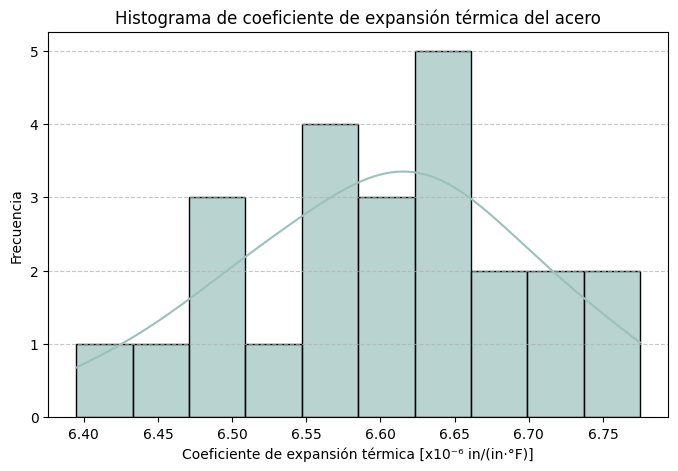

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(datos, bins=10, edgecolor='black', alpha=0.7, color='#9BC1BC', kde=True)
plt.ylabel("Frecuencia")
plt.xlabel("Coeficiente de expansión térmica [x10⁻⁶ in/(in·°F)]")
plt.title("Histograma de coeficiente de expansión térmica del acero")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()